# Model Predictions Viewer
Quick tool to view predictions from different models

In [1]:
# GPU Environment Setup
import os
import sys

# Set environment variables for GPU and threading
os.environ['SLURM_CPU_BIND'] = 'cores'
os.environ['NUMEXPR_MAX_THREADS'] = '128'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_NUM_INTEROP_THREADS'] = '8'
os.environ['TF_NUM_INTRAOP_THREADS'] = '16'
os.environ['OMP_NUM_THREADS'] = '16'
os.environ['PYTHONUNBUFFERED'] = '1'

print("GPU environment configured!")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")

# Verify GPU access
try:
    !nvidia-smi -L
except:
    print("Warning: nvidia-smi not available")

GPU environment configured!
CUDA_VISIBLE_DEVICES: 0
GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-aa4d5445-7084-682d-b490-7eaca4817413)
GPU 1: NVIDIA A100-SXM4-40GB (UUID: GPU-0b85e944-1bb5-a697-8884-21627b28988d)
GPU 2: NVIDIA A100-SXM4-40GB (UUID: GPU-fddb7735-2fa3-7c99-8b46-19f0793380b4)
GPU 3: NVIDIA A100-SXM4-40GB (UUID: GPU-7c9f430e-34a4-6060-b6a5-8c2973e139d1)


In [25]:
# Load and View Model Predictions
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


def view_predictions(model_name, n=10, base_path='../models'):
    """
    Load and display predictions from a model.
    
    Parameters:
    -----------
    model_name : str
        Name of the model folder under models/
    n : int
        Number of predictions to display (default: 10)
    base_path : str
        Base path to models directory (default: 'models')
    """
    # Construct path to predictions file
    pred_file = Path(base_path) / model_name / 'predictions.npz'
    
    if not pred_file.exists():
        print(f"❌ File not found: {pred_file}")
        return None
    
    # Load predictions
    print(f"📂 Loading: {pred_file}")
    data = np.load(pred_file)
    
    # Extract arrays
    y_true = data['y_true']
    y_pred = data['y_pred']
    errors = data['errors']
    
    # Create DataFrame for better visualization
    df = pd.DataFrame({
        'Index': range(len(y_true)),
        'y_true': y_true,
        'y_pred': y_pred,
        'error': errors
    })
    
    # Print summary statistics
    print(f"\nSummary Statistics for {model_name}")
    print(f"{'='*60}")
    print(f"Total samples: {len(y_true)}")
    print(f"\nError Statistics:")
    print(f"  Mean Error:   {errors.mean():.6f}")
    print(f"  Std Error:    {errors.std():.6f}")
    print(f"  Min Error:    {errors.min():.6f}")
    print(f"  Max Error:    {errors.max():.6f}")
    print(f"  Median Error: {np.median(errors):.6f}")
    
    # Display first n predictions
    print(f"\n📋 First {n} Predictions:")
    print(f"{'='*60}")
    display(df.head(n))
    
    return df

def verify_identical_ytrue(model1_name, model2_name, base_path='../models'):
    """
    Verify that y_true values are identical between two models.
    
    Parameters:
    -----------
    model1_name : str
        Name of the first model
    model2_name : str
        Name of the second model
    base_path : str
        Base path to models directory
    """
    # Load predictions from both models
    pred_file1 = Path(base_path) / model1_name / 'predictions.npz'
    pred_file2 = Path(base_path) / model2_name / 'predictions.npz'
    
    data1 = np.load(pred_file1)
    data2 = np.load(pred_file2)
    
    y_true1 = data1['y_true']
    y_true2 = data2['y_true']
    
    # Check size
    size_match = len(y_true1) == len(y_true2)
    print(f"✓ Size check: Model1={len(y_true1)}, Model2={len(y_true2)} → {'PASS' if size_match else 'FAIL'}")
    
    # Check values
    if size_match:
        values_match = np.allclose(y_true1, y_true2)
        exact_match = np.array_equal(y_true1, y_true2)
        
        print(f"✓ Values identical (exact): {'PASS ✅' if exact_match else 'FAIL ❌'}")
        
        if not exact_match:
            print(f"✓ Values close (tolerance): {'PASS ⚠️' if values_match else 'FAIL ❌'}")
            max_diff = np.abs(y_true1 - y_true2).max()
            print(f"  Max difference: {max_diff:.10f}")
    else:
        print("❌ Cannot compare values - sizes don't match!")

def compare_model_errors_2d(model1_name, model2_name, 
                            model1_label=None, model2_label=None,
                            base_path='../models'):
    """
    Create a 2D histogram comparing errors from two models.
    
    Parameters:
    -----------
    model1_name : str
        Name of the first model (x-axis)
    model2_name : str
        Name of the second model (y-axis)
    model1_label : str, optional
        Physical meaning label for model 1 (e.g., "LAr-only")
    model2_label : str, optional
        Physical meaning label for model 2 (e.g., "LAr+HGTD")
    base_path : str
        Base path to models directory
    """
    # Use model names as labels if not provided
    if model1_label is None:
        model1_label = model1_name
    if model2_label is None:
        model2_label = model2_name
    
    # Load predictions from both models
    pred_file1 = Path(base_path) / model1_name / 'predictions.npz'
    pred_file2 = Path(base_path) / model2_name / 'predictions.npz'
    
    if not pred_file1.exists():
        print(f"❌ File not found: {pred_file1}")
        return
    if not pred_file2.exists():
        print(f"❌ File not found: {pred_file2}")
        return
    
    # Load data
    data1 = np.load(pred_file1)
    data2 = np.load(pred_file2)
    
    errors1 = data1['errors']
    errors2 = data2['errors']
    
    # Check if same number of samples
    if len(errors1) != len(errors2):
        print(f"⚠️ Warning: Different number of samples ({len(errors1)} vs {len(errors2)})")
        min_len = min(len(errors1), len(errors2))
        errors1 = errors1[:min_len]
        errors2 = errors2[:min_len]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create 2D histogram
    h = ax.hist2d(errors1, errors2, bins=100, cmap='viridis', 
                   cmin=1, norm=plt.matplotlib.colors.LogNorm())
    
    # Add colorbar
    cbar = plt.colorbar(h[3], ax=ax)
    cbar.set_label('Count (log scale)', fontsize=12)
    
    # Add diagonal line (y=x)
    lim_min = min(errors1.min(), errors2.min())
    lim_max = max(errors1.max(), errors2.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 
             'r--', linewidth=2, label='y=x', alpha=0.7)
    
    # Add zero lines
    ax.axhline(y=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
    
    # Calculate correlation
    correlation = np.corrcoef(errors1, errors2)[0, 1]
    
    # Labels and title
    ax.set_xlabel(f'{model1_label} $\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    ax.set_ylabel(f'{model2_label} $\\Delta t_0$ [ps]', fontsize=13, fontweight='bold')
    ax.set_title('2D Histogram: Delta t0 Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 Comparison Summary")
    print(f"{'='*60}")
    print(f"Model 1: {model1_label} ({model1_name})")
    print(f"  Mean Error: {errors1.mean():.4f} ps")
    print(f"  Std Error:  {errors1.std():.4f} ps")
    print(f"\nModel 2: {model2_label} ({model2_name})")
    print(f"  Mean Error: {errors2.mean():.4f} ps")
    print(f"  Std Error:  {errors2.std():.4f} ps")
    print(f"\nCorrelation: {correlation:.4f}")
    print(f"Total Samples: {len(errors1)}")

In [19]:
# Run verification
verify_identical_ytrue('hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr')

# Example 1: View first 10 predictions (default)
# df = view_predictions('test_1209_LAr_1e2', n=20)

# Example 3: View multiple models
for model in ['hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr']:
    view_predictions(model, n=5)
    print('\n' + '='*80 + '\n')

✓ Size check: Model1=8876, Model2=8876 → PASS
✓ Values identical (exact): PASS ✅
📂 Loading: ../models/hgtd_multi_input_dnn_with_jets_tracks/predictions.npz

Summary Statistics for hgtd_multi_input_dnn_with_jets_tracks
Total samples: 8876

Error Statistics:
  Mean Error:   -0.494620
  Std Error:    73.423676
  Min Error:    -503.848877
  Max Error:    577.704468
  Median Error: -0.364219

📋 First 5 Predictions:


,Index,y_true,y_pred,error
0,0,-142.325104,-8.098275,134.226822
1,1,-202.486069,-189.475845,13.010223
2,2,-62.909557,-65.645531,-2.735973
3,3,-52.310635,-56.101036,-3.790401
4,4,-50.675278,-44.744549,5.930729




📂 Loading: ../models/test_1209_LAr/predictions.npz

Summary Statistics for test_1209_LAr
Total samples: 8876

Error Statistics:
  Mean Error:   -7.739401
  Std Error:    106.656372
  Min Error:    -576.327515
  Max Error:    613.531494
  Median Error: -8.866297

📋 First 5 Predictions:


,Index,y_true,y_pred,error
0,0,-142.325104,-29.212627,113.112473
1,1,-202.486069,-163.033585,39.452484
2,2,-62.909557,-99.885468,-36.975910
3,3,-52.310635,-39.682934,12.627701
4,4,-50.675278,-46.017719,4.657558


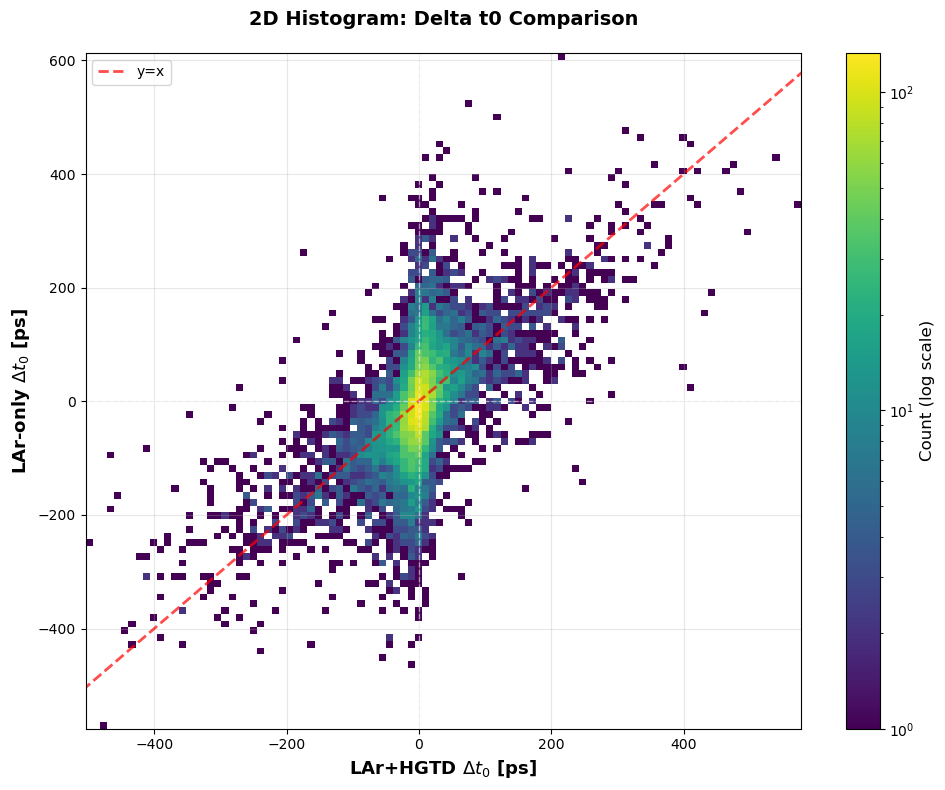


📊 Comparison Summary
Model 1: LAr+HGTD (hgtd_multi_input_dnn_with_jets_tracks)
  Mean Error: -0.4946 ps
  Std Error:  73.4237 ps

Model 2: LAr-only (test_1209_LAr)
  Mean Error: -7.7394 ps
  Std Error:  106.6564 ps

Correlation: 0.6001
Total Samples: 8876


In [26]:
# Run the comparison
compare_model_errors_2d('hgtd_multi_input_dnn_with_jets_tracks', 'test_1209_LAr',
                        model1_label='LAr+HGTD', model2_label='LAr-only')